In [59]:
%pip install -U pandas pyarrow fastparquet numpy plotly matplotlib seaborn scipy tqdm duckdb polars openpyxl jupyterlab

  Using cached fastparquet-2026.5.0-cp311-cp311-win_amd64.whl (698 kB)
  Using cached jupyterlab-4.6.2-py3-none-any.whl (17.2 MB)
  Using cached cramjam-2.11.0-cp311-cp311-win_amd64.whl (1.7 MB)
  Using cached fsspec-2026.7.0-py3-none-any.whl (206 kB)
  Using cached async_lru-2.3.0-py3-none-any.whl (8.4 kB)
  Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
  Using cached jupyter_builder-1.2.0-py3-none-any.whl (914 kB)
  Using cached jupyter_lsp-2.3.1-py3-none-any.whl (77 kB)
  Using cached jupyter_server-2.20.0-py3-none-any.whl (393 kB)
  Using cached jupyterlab_server-2.28.0-py3-none-any.whl (59 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl (13 kB)
  Using cached anyio-4.14.2-py3-none-any.whl (125 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl (136 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
  Using cached idna-3.18-py3-none-any.whl (65 kB)
  Using cached h11-0.16.0-py3-none-any.whl (37 kB)
  Usin

ERROR: Could not install packages due to an OSError: [WinError 2] The system cannot find the file specified: 'c:\\Python311\\Scripts\\idna.exe' -> 'c:\\Python311\\Scripts\\idna.exe.deleteme'


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
import pandas as pd
import numpy as np
import duckdb
import polars as pl
import plotly
import matplotlib
import seaborn as sns
import scipy
from tqdm import tqdm

print("✅ All required libraries imported successfully!")

✅ All required libraries imported successfully!


In [61]:
import pandas as pd

parquet_file = r"C:\Users\developer_02\Desktop\data_AIS\AIS_parquet\ais_destination_cleaned_v3.parquet"

df = pd.read_parquet(parquet_file)

print(df.shape)

(1023554, 23)


In [62]:
print(df.head())

print("\n")
print(df.info())

print("\n")
print(df.describe(include="all"))

   row_index  mmsi                                voyage_id  \
0          0     1  VMV0000000001-6b86b273-e3b0c442-NAD-NAT   
1          1     1  VMV0000000001-6b86b273-10314348-NAD-NAT   
2          2     5  VMV0000000005-ef2d127d-1a03ef9f-NAD-NAT   
3          3     5  VMV0000000005-ef2d127d-1a03ef9f-NAD-NAT   
4          4     5  VMV0000000005-ef2d127d-cee1aeba-NAD-NAT   

            vessel_name destination         timestamp_updated   latitude  \
0  FISHING NET BOYA-89%         NaN 2026-06-01 23:47:32+00:00  24.990640   
1  FISHING NET BOYA-88%         NaN 2026-06-01 23:57:13+00:00  24.990665   
2  LONGLINE BUOY 05-69%         NaN 2026-06-01 23:10:24+00:00 -32.207008   
3  LONGLINE BUOY 05-69%         NaN 2026-06-01 23:14:20+00:00 -32.207082   
4                  JX-7         NaN 2026-06-01 23:37:09+00:00 -32.207687   

   longitude dest_clean matched_label  ...  matched_accepted label_15min  \
0  56.857433        NaN           NaN  ...               NaN         NaN   
1  56.857498

<class 'pandas.DataFrame'>
RangeIndex: 1023554 entries, 0 to 1023553
Data columns (total 23 columns):
 #   Column                Non-Null Count    Dtype              
---  ------                --------------    -----              
 0   row_index             1023554 non-null  int64              
 1   mmsi                  1023554 non-null  int32              
 2   voyage_id             1023554 non-null  str                
 3   vessel_name           989337 non-null   str                
 4   destination           854269 non-null   str                
 5   timestamp_updated     1023554 non-null  datetime64[us, UTC]
 6   latitude              1023554 non-null  float64            
 7   longitude             1023554 non-null  float64            
 8   dest_clean            839642 non-null   str                
 9   matched_label         833549 non-null   str                
 10  similarity_score      1023554 non-null  int64              
 11  match_method          1023554 non-null  str     

In [63]:
# Print all column names one per line

print(f"Total Columns: {len(df.columns)}\n")

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Total Columns: 23

1. row_index
2. mmsi
3. voyage_id
4. vessel_name
5. destination
6. timestamp_updated
7. latitude
8. longitude
9. dest_clean
10. matched_label
11. similarity_score
12. match_method
13. match_kind
14. matched_accepted
15. label_15min
16. label_10min
17. label_5min
18. label_3min
19. destination_mapped
20. destination_final
21. status
22. transform_method
23. destination_original


In [64]:
import pandas as pd

parquet_file = r"C:\Users\developer_02\Desktop\data_AIS\AIS_parquet\ais_destination_cleaned_v3.parquet"

df = pd.read_parquet(parquet_file)

print(df.shape)

(1023554, 23)


In [65]:
destination_df = df[
    [
        "mmsi",
        "timestamp_updated",
        "destination"
    ]
].copy()

print("=" * 60)
print("Working DataFrame Created Successfully")
print("=" * 60)

print(f"Rows    : {destination_df.shape[0]:,}")
print(f"Columns : {destination_df.shape[1]}")

print("\nColumns Selected:")
print(destination_df.columns.tolist())

destination_df.head()

Working DataFrame Created Successfully
Rows    : 1,023,554
Columns : 3

Columns Selected:
['mmsi', 'timestamp_updated', 'destination']


,mmsi,timestamp_updated,destination
0,1,2026-06-01 23:47:32+00:00,NaN
1,1,2026-06-01 23:57:13+00:00,NaN
2,5,2026-06-01 23:10:24+00:00,NaN
3,5,2026-06-01 23:14:20+00:00,NaN
4,5,2026-06-01 23:37:09+00:00,NaN


In [66]:
# ==========================================================
# Cell 4 : Data Cleaning
# ==========================================================

import pandas as pd
import numpy as np

print("="*60)
print("Cleaning Data...")
print("="*60)

# Convert timestamp
destination_df["timestamp_updated"] = pd.to_datetime(
    destination_df["timestamp_updated"],
    errors="coerce"
)

# Remove rows having null values
destination_df = destination_df.dropna(
    subset=[
        "mmsi",
        "timestamp_updated",
        "destination"
    ]
)

# Remove leading/trailing spaces
destination_df["destination"] = (
    destination_df["destination"]
    .astype(str)
    .str.strip()
)

# Remove blank destinations
destination_df = destination_df[
    destination_df["destination"] != ""
]

# Remove duplicate AIS messages
destination_df = destination_df.drop_duplicates()

print("Cleaning Completed Successfully")

print("\nDataset Shape :", destination_df.shape)

destination_df.head()

Cleaning Data...
Cleaning Completed Successfully

Dataset Shape : (851938, 3)


,mmsi,timestamp_updated,destination
71,999,2026-06-01 23:00:03+00:00,FOR ORDERS
72,999,2026-06-01 23:13:44+00:00,FOR ORDERS
73,999,2026-06-01 23:45:22+00:00,FOR ORDERS
74,1111,2026-06-01 23:00:54+00:00,Trapani
75,1111,2026-06-01 23:11:05+00:00,Trapani


In [67]:
# ==========================================================
# Cell 5 : Sort Data
# ==========================================================

destination_df = (
    destination_df
    .sort_values(
        by=[
            "mmsi",
            "timestamp_updated"
        ]
    )
    .reset_index(drop=True)
)

print("="*60)
print("Data Sorted Successfully")
print("="*60)

destination_df.head()

Data Sorted Successfully


,mmsi,timestamp_updated,destination
0,999,2026-06-01 23:00:03+00:00,FOR ORDERS
1,999,2026-06-01 23:13:44+00:00,FOR ORDERS
2,999,2026-06-01 23:45:22+00:00,FOR ORDERS
3,1111,2026-06-01 23:00:54+00:00,Trapani
4,1111,2026-06-01 23:11:05+00:00,Trapani


In [68]:
# ==========================================================
# Cell 6 : Previous Destination & Previous Timestamp
# ==========================================================

destination_df["previous_destination"] = (
    destination_df
    .groupby("mmsi")["destination"]
    .shift(1)
)

destination_df["previous_timestamp"] = (
    destination_df
    .groupby("mmsi")["timestamp_updated"]
    .shift(1)
)

print("="*60)
print("Previous Destination & Timestamp Added")
print("="*60)

destination_df.head(10)

Previous Destination & Timestamp Added


,mmsi,timestamp_updated,destination,previous_destination,previous_timestamp
0,999,2026-06-01 23:00:03+00:00,FOR ORDERS,NaN,NaT
1,999,2026-06-01 23:13:44+00:00,FOR ORDERS,FOR ORDERS,2026-06-01 23:00:03+00:00
2,999,2026-06-01 23:45:22+00:00,FOR ORDERS,FOR ORDERS,2026-06-01 23:13:44+00:00
3,1111,2026-06-01 23:00:54+00:00,Trapani,NaN,NaT
4,1111,2026-06-01 23:11:05+00:00,Trapani,Trapani,2026-06-01 23:00:54+00:00
5,1111,2026-06-01 23:16:06+00:00,Trapani,Trapani,2026-06-01 23:11:05+00:00
6,1111,2026-06-01 23:20:34+00:00,Trapani,Trapani,2026-06-01 23:16:06+00:00
7,1111,2026-06-01 23:26:05+00:00,Trapani,Trapani,2026-06-01 23:20:34+00:00
8,171069,2026-06-01 23:03:46+00:00,Marin,NaN,NaT
9,420393,2026-06-01 23:16:49+00:00,"Saint Helena, Ascension, and Tristan da Cunha",NaN,NaT


In [69]:
# ==========================================================
# Cell 7 : Destination Change Detection
# ==========================================================

destination_df["destination_changed"] = (
    (
        destination_df["destination"] !=
        destination_df["previous_destination"]
    )
    &
    destination_df["previous_destination"].notna()
)

print("="*60)
print("Destination Change Detection Completed")
print("="*60)

print(
    "Total Destination Change Events :",
    destination_df["destination_changed"].sum()
)

destination_df.head(20)

Destination Change Detection Completed
Total Destination Change Events : 4561


,mmsi,timestamp_updated,destination,previous_destination,previous_timestamp,destination_changed
0,999,2026-06-01 23:00:03+00:00,FOR ORDERS,NaN,NaT,False
1,999,2026-06-01 23:13:44+00:00,FOR ORDERS,FOR ORDERS,2026-06-01 23:00:03+00:00,False
2,999,2026-06-01 23:45:22+00:00,FOR ORDERS,FOR ORDERS,2026-06-01 23:13:44+00:00,False
3,1111,2026-06-01 23:00:54+00:00,Trapani,NaN,NaT,False
4,1111,2026-06-01 23:11:05+00:00,Trapani,Trapani,2026-06-01 23:00:54+00:00,False
5,1111,2026-06-01 23:16:06+00:00,Trapani,Trapani,2026-06-01 23:11:05+00:00,False
6,1111,2026-06-01 23:20:34+00:00,Trapani,Trapani,2026-06-01 23:16:06+00:00,False
7,1111,2026-06-01 23:26:05+00:00,Trapani,Trapani,2026-06-01 23:20:34+00:00,False
8,171069,2026-06-01 23:03:46+00:00,Marin,NaN,NaT,False
9,420393,2026-06-01 23:16:49+00:00,"Saint Helena, Ascension, and Tristan da Cunha",NaN,NaT,False


In [70]:
# ==========================================================
# Cell 8 : Destination Change Event Table
# ==========================================================

destination_change_events = (
    destination_df[
        destination_df["destination_changed"]
    ]
    .copy()
)

# Time difference
destination_change_events["time_gap_hours"] = (
    (
        destination_change_events["timestamp_updated"] -
        destination_change_events["previous_timestamp"]
    )
    .dt.total_seconds() / 3600
)

destination_change_events = destination_change_events[
    [
        "mmsi",
        "previous_timestamp",
        "timestamp_updated",
        "previous_destination",
        "destination",
        "time_gap_hours"
    ]
]

destination_change_events = destination_change_events.rename(
    columns={
        "timestamp_updated":"current_timestamp",
        "destination":"current_destination"
    }
)

print("="*60)
print("Destination Change Event Table Created")
print("="*60)

print(
    "Total Change Events :",
    len(destination_change_events)
)

destination_change_events.head(20)

Destination Change Event Table Created
Total Change Events : 4561


,mmsi,previous_timestamp,current_timestamp,previous_destination,current_destination,time_gap_hours
326,20127875,2026-06-01 23:11:14+00:00,2026-06-01 23:17:20+00:00,Al Khair Oil Terminal,Angola,0.101667
327,20127875,2026-06-01 23:17:20+00:00,2026-06-01 23:23:10+00:00,Angola,Al Khair Oil Terminal,0.097222
329,20127875,2026-06-01 23:23:15+00:00,2026-06-01 23:26:10+00:00,Al Khair Oil Terminal,Angola,0.048611
332,20127875,2026-06-01 23:38:13+00:00,2026-06-01 23:41:11+00:00,Angola,Santander,0.049444
335,20127875,2026-06-01 23:47:13+00:00,2026-06-01 23:50:10+00:00,Santander,Angola,0.049167
471,111000000,2026-06-01 23:26:54+00:00,2026-06-01 23:27:13+00:00,Turkey,Phsar Ream,0.005278
947,205268000,2026-06-01 23:38:02+00:00,2026-06-01 23:44:03+00:00,Peru,Singapore,0.100278
949,205268000,2026-06-01 23:47:05+00:00,2026-06-01 23:50:05+00:00,Singapore,Peru,0.050000
1995,205664000,2026-06-01 23:21:55+00:00,2026-06-01 23:25:01+00:00,Philippines,China,0.051667
1998,205664000,2026-06-01 23:26:56+00:00,2026-06-01 23:31:01+00:00,China,Philippines,0.068056


In [71]:
# ==========================================================
# Cell 9 : Export Destination Change Event Table
# ==========================================================

output_file = "Destination_Change_Events.csv"

destination_change_events.to_csv(
    output_file,
    index=False
)

print("="*60)
print("Destination Change Events Exported Successfully")
print("="*60)

print("Saved As :", output_file)

Destination Change Events Exported Successfully
Saved As : Destination_Change_Events.csv


In [72]:
# ==========================================================
# Cell 10 : Vessel Summary
# ==========================================================

# Total AIS reports per vessel
total_reports = (
    destination_df
    .groupby("mmsi")
    .size()
    .reset_index(name="total_reports")
)

# Destination change summary
vessel_summary = (
    destination_change_events
    .groupby("mmsi")
    .agg(
        destination_change_count=("current_destination", "count"),
        avg_time_gap_hours=("time_gap_hours", "mean"),
        min_time_gap_hours=("time_gap_hours", "min"),
        max_time_gap_hours=("time_gap_hours", "max"),
        first_change=("previous_timestamp", "min"),
        latest_change=("current_timestamp", "max")
    )
    .reset_index()
)

# Merge total reports
vessel_summary = vessel_summary.merge(
    total_reports,
    on="mmsi",
    how="left"
)

# Round values
vessel_summary["avg_time_gap_hours"] = (
    vessel_summary["avg_time_gap_hours"]
    .round(2)
)

vessel_summary["min_time_gap_hours"] = (
    vessel_summary["min_time_gap_hours"]
    .round(2)
)

vessel_summary["max_time_gap_hours"] = (
    vessel_summary["max_time_gap_hours"]
    .round(2)
)

print(vessel_summary.head())

        mmsi  destination_change_count  avg_time_gap_hours  \
0   20127875                         5                0.07   
1  111000000                         1                0.01   
2  205268000                         2                0.08   
3  205664000                         2                0.06   
4  205744000                         3                0.08   

   min_time_gap_hours  max_time_gap_hours              first_change  \
0                0.05                0.10 2026-06-01 23:11:14+00:00   
1                0.01                0.01 2026-06-01 23:26:54+00:00   
2                0.05                0.10 2026-06-01 23:38:02+00:00   
3                0.05                0.07 2026-06-01 23:21:55+00:00   
4                0.05                0.10 2026-06-01 23:28:48+00:00   

              latest_change  total_reports  
0 2026-06-01 23:50:10+00:00             16  
1 2026-06-01 23:27:13+00:00            246  
2 2026-06-01 23:50:05+00:00             22  
3 2026-06-01 23:31:0

In [73]:
# ==========================================================
# Cell 11 : KPI Calculations
# ==========================================================

total_vessels = destination_df["mmsi"].nunique()

total_change_events = len(destination_change_events)

vessels_with_changes = vessel_summary["mmsi"].nunique()

max_changes = vessel_summary["destination_change_count"].max()

average_changes = (
    vessel_summary["destination_change_count"]
    .mean()
)

print("="*60)

print(f"Total Vessels Analysed           : {total_vessels:,}")

print(f"Total Destination Change Events  : {total_change_events:,}")

print(f"Vessels With Destination Changes : {vessels_with_changes:,}")

print(f"Maximum Destination Changes      : {max_changes}")

print(f"Average Destination Changes      : {average_changes:.2f}")

print("="*60)

Total Vessels Analysed           : 19,721
Total Destination Change Events  : 4,561
Vessels With Destination Changes : 1,922
Maximum Destination Changes      : 11
Average Destination Changes      : 2.37


In [74]:
# ==========================================================
# Cell 12 : Top Destination Changers
# ==========================================================

top_destination_changers = (
    vessel_summary
    .sort_values(
        by="destination_change_count",
        ascending=False
    )
    .reset_index(drop=True)
)

top20_destination_changers = top_destination_changers.head(20)

display(top20_destination_changers)

,mmsi,destination_change_count,avg_time_gap_hours,min_time_gap_hours,max_time_gap_hours,first_change,latest_change,total_reports
0,461000204,11,0.00,0.00,0.01,2026-06-01 23:05:57+00:00,2026-06-01 23:54:00+00:00,430
1,311001237,11,0.00,0.00,0.01,2026-06-01 23:04:59+00:00,2026-06-01 23:57:08+00:00,320
2,353975000,11,0.00,0.00,0.01,2026-06-01 23:02:41+00:00,2026-06-01 23:54:05+00:00,314
3,525016299,10,0.00,0.00,0.01,2026-06-01 23:02:55+00:00,2026-06-01 23:51:03+00:00,279
4,667002305,10,0.01,0.01,0.02,2026-06-01 23:05:40+00:00,2026-06-01 23:54:23+00:00,93
5,413050320,10,0.01,0.00,0.01,2026-06-01 23:02:34+00:00,2026-06-01 23:57:24+00:00,287
6,413884867,9,0.02,0.01,0.02,2026-06-01 23:02:57+00:00,2026-06-01 23:42:06+00:00,124
7,636013800,9,0.01,0.00,0.01,2026-06-01 23:05:54+00:00,2026-06-01 23:57:03+00:00,266
8,538011596,8,0.00,0.00,0.01,2026-06-01 23:08:42+00:00,2026-06-01 23:42:14+00:00,295
9,538011532,8,0.02,0.00,0.07,2026-06-01 23:01:24+00:00,2026-06-01 23:51:09+00:00,323


In [75]:
# ==========================================================
# Cell 13 : Destination Transition Analysis
# ==========================================================

destination_transitions = (
    destination_change_events
    .groupby(
        [
            "previous_destination",
            "current_destination"
        ]
    )
    .size()
    .reset_index(name="transition_count")
)

destination_transitions = (
    destination_transitions
    .sort_values(
        by="transition_count",
        ascending=False
    )
)

display(destination_transitions.head(20))

,previous_destination,current_destination,transition_count
1866,Peru,Singapore,26
2328,Senj,China,22
465,China,Senj,22
2397,Singapore,Peru,20
824,Guangzhou,Guam,17
813,Guam,Guangzhou,15
2895,Zhangjiangang,Zhangzhou,15
1491,Mauritius,Mundra,14
1617,Nash Harbor,Namibia,14
2507,Sri Lanka,Colombia,13


In [76]:
# ==========================================================
# Cell 14 : Destination Change Timeline
# Change selected_mmsi to any MMSI from the destination_change_events DataFrame to view its timeline.
# ==========================================================

selected_mmsi = destination_change_events.iloc[0]["mmsi"]

timeline = (
    destination_change_events[
        destination_change_events["mmsi"] == selected_mmsi
    ]
    .sort_values("current_timestamp")
)

print(f"Timeline for MMSI : {selected_mmsi}")

display(timeline)

Timeline for MMSI : 20127875


,mmsi,previous_timestamp,current_timestamp,previous_destination,current_destination,time_gap_hours
326,20127875,2026-06-01 23:11:14+00:00,2026-06-01 23:17:20+00:00,Al Khair Oil Terminal,Angola,0.101667
327,20127875,2026-06-01 23:17:20+00:00,2026-06-01 23:23:10+00:00,Angola,Al Khair Oil Terminal,0.097222
329,20127875,2026-06-01 23:23:15+00:00,2026-06-01 23:26:10+00:00,Al Khair Oil Terminal,Angola,0.048611
332,20127875,2026-06-01 23:38:13+00:00,2026-06-01 23:41:11+00:00,Angola,Santander,0.049444
335,20127875,2026-06-01 23:47:13+00:00,2026-06-01 23:50:10+00:00,Santander,Angola,0.049167


In [77]:
# ==========================================================
# Cell 15 : Recent Destination Changes
# ==========================================================

recent_destination_changes = (
    destination_change_events
    .sort_values(
        by="current_timestamp",
        ascending=False
    )
)

display(recent_destination_changes.head(20))

,mmsi,previous_timestamp,current_timestamp,previous_destination,current_destination,time_gap_hours
378667,466250000,2026-06-01 23:53:19+00:00,2026-06-01 23:59:59+00:00,General Santos,Corpach,0.111111
265966,413268980,2026-06-01 23:53:01+00:00,2026-06-01 23:59:59+00:00,China,Wenzhou,0.116111
82083,305027400,2026-06-01 23:56:37+00:00,2026-06-01 23:59:50+00:00,Blaine,Oman,0.053611
432819,525006047,2026-06-01 23:56:50+00:00,2026-06-01 23:59:49+00:00,Tg. Sorong,Tuban,0.049722
235206,405000246,2026-06-01 23:55:42+00:00,2026-06-01 23:59:47+00:00,India,Bangladesh,0.068056
357800,422336699,2026-06-01 23:54:33+00:00,2026-06-01 23:59:45+00:00,Japan,Huangpu,0.086667
608037,563097100,2026-06-01 23:56:38+00:00,2026-06-01 23:59:38+00:00,Peru,Port Wing,0.050000
34345,232064745,2026-06-01 23:54:34+00:00,2026-06-01 23:59:36+00:00,Al Jubayl,Ju Aymah Oil Terminal,0.083889
572652,538012480,2026-06-01 23:53:20+00:00,2026-06-01 23:59:31+00:00,Iran,Malaysia,0.103056
117928,352001481,2026-06-01 23:56:55+00:00,2026-06-01 23:59:25+00:00,North Ain Sukhna Port,Port Socony,0.041667


In [78]:
# ==========================================================
# Cell 16 : Export Summary
# ==========================================================

vessel_summary.to_csv(
    "Destination_Change_Summary.csv",
    index=False
)

destination_transitions.to_csv(
    "Destination_Transitions.csv",
    index=False
)

top20_destination_changers.to_csv(
    "Top20_Destination_Changers.csv",
    index=False
)

recent_destination_changes.to_csv(
    "Recent_Destination_Changes.csv",
    index=False
)

print("="*60)

print("Files Exported Successfully")

print("="*60)

print("1. Destination_Change_Summary.csv")

print("2. Destination_Transitions.csv")

print("3. Top20_Destination_Changers.csv")

print("4. Recent_Destination_Changes.csv")

Files Exported Successfully
1. Destination_Change_Summary.csv
2. Destination_Transitions.csv
3. Top20_Destination_Changers.csv
4. Recent_Destination_Changes.csv


In [79]:
# ==========================================================
# Cell 17 : Imports & Styling
# ==========================================================

import matplotlib.pyplot as plt

# Professional plotting parameters
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Professional plotting style loaded.")

Professional plotting style loaded.


In [80]:
# ==========================================================
# Cell 18 : KPI Cards
# ==========================================================

total_vessels = destination_df["mmsi"].nunique()

total_change_events = len(destination_change_events)

vessels_with_changes = destination_change_events["mmsi"].nunique()

max_changes = vessel_summary["destination_change_count"].max()

avg_changes = vessel_summary["destination_change_count"].mean()

print("="*70)
print("DESTINATION CHANGE DASHBOARD - KPI SUMMARY")
print("="*70)

print(f"Total Vessels Analysed            : {total_vessels:,}")

print(f"Destination Change Events         : {total_change_events:,}")

print(f"Vessels With Destination Changes  : {vessels_with_changes:,}")

print(f"Maximum Destination Changes       : {max_changes}")

print(f"Average Destination Changes       : {avg_changes:.2f}")

print("="*70)

DESTINATION CHANGE DASHBOARD - KPI SUMMARY
Total Vessels Analysed            : 19,721
Destination Change Events         : 4,561
Vessels With Destination Changes  : 1,922
Maximum Destination Changes       : 11
Average Destination Changes       : 2.37


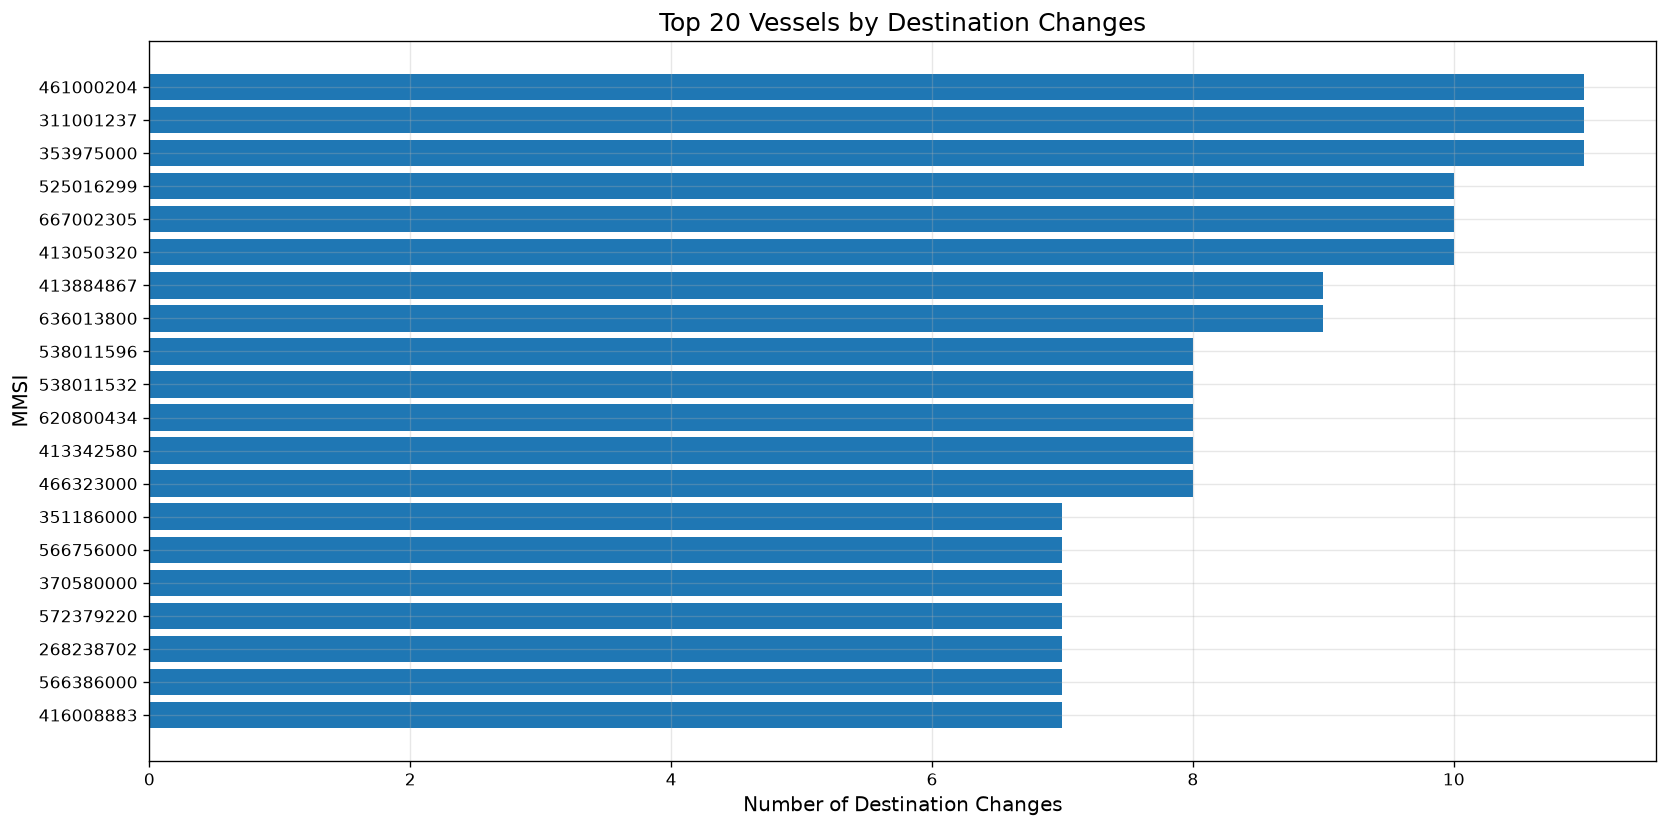

In [81]:
# ==========================================================
# Cell 19 : Top Destination Changers
# ==========================================================

top20 = (
    vessel_summary
    .sort_values(
        "destination_change_count",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(14,7))

plt.barh(
    top20["mmsi"].astype(str),
    top20["destination_change_count"]
)

plt.xlabel("Number of Destination Changes")

plt.ylabel("MMSI")

plt.title("Top 20 Vessels by Destination Changes")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

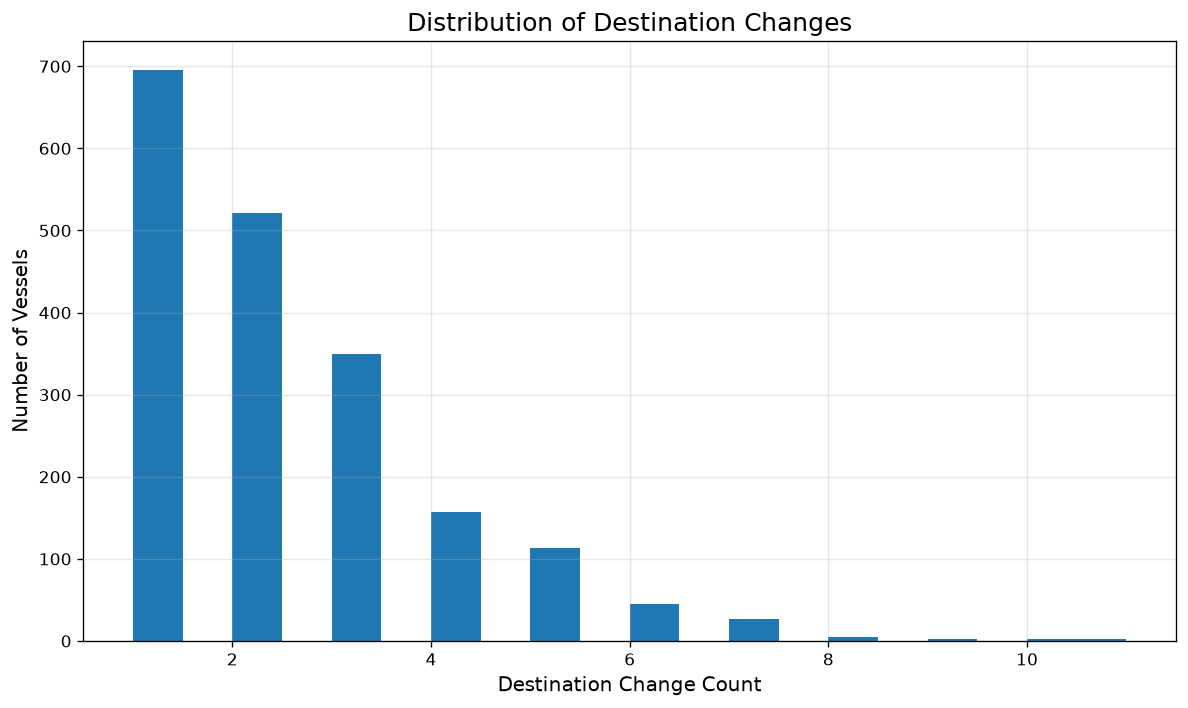

In [82]:
# ==========================================================
# Cell 20 : Distribution of Destination Changes
# ==========================================================

plt.figure(figsize=(10,6))

plt.hist(
    vessel_summary["destination_change_count"],
    bins=20
)

plt.xlabel("Destination Change Count")

plt.ylabel("Number of Vessels")

plt.title("Distribution of Destination Changes")

plt.tight_layout()

plt.show()

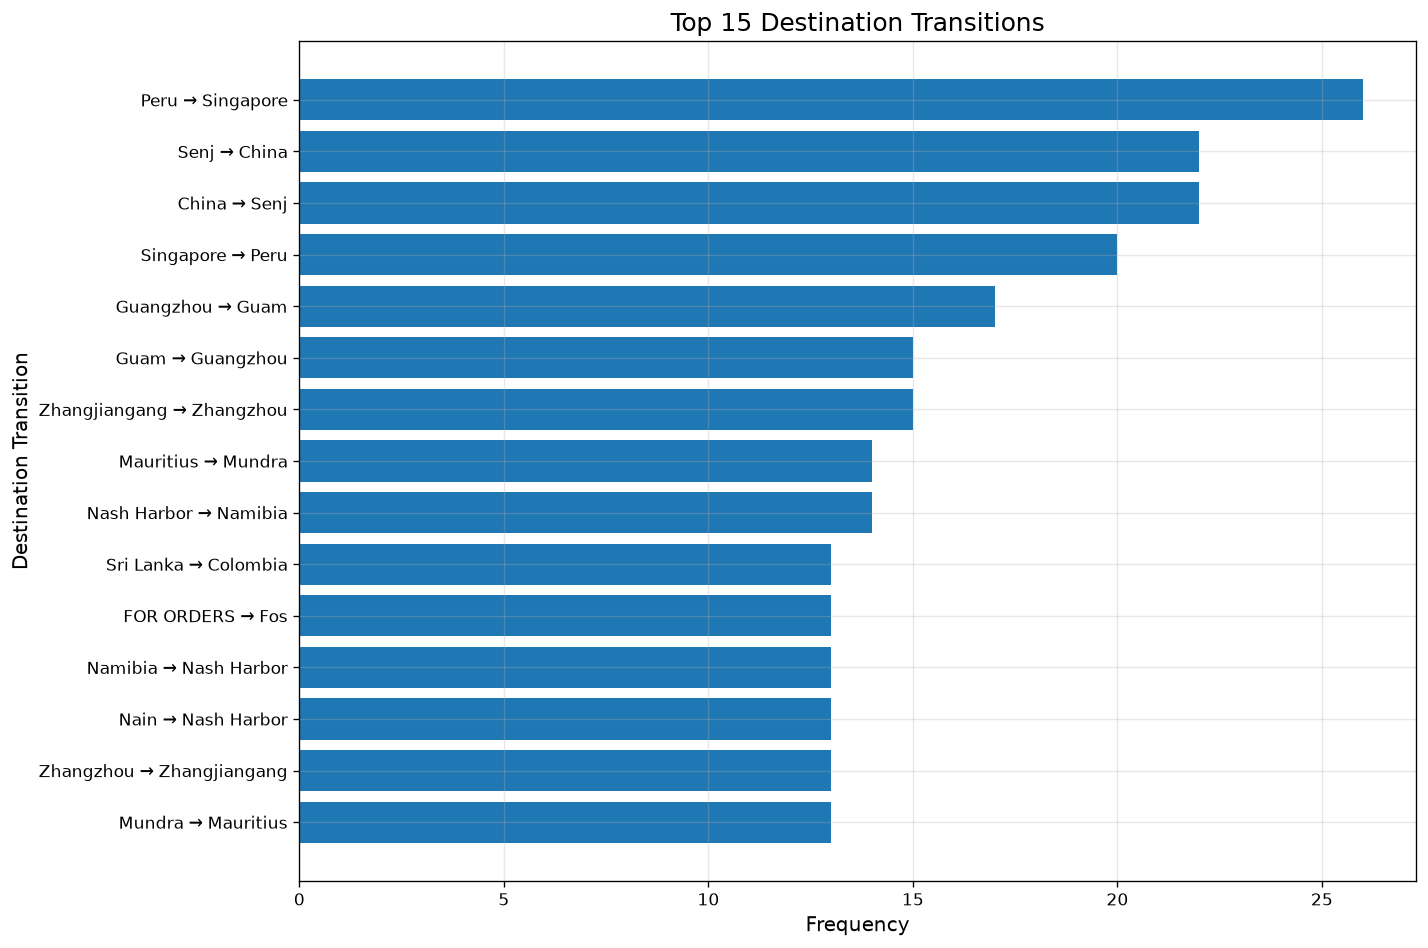

In [83]:
# ==========================================================
# Cell 21 : Top Destination Transitions
# ==========================================================

top_transitions = (
    destination_transitions
    .head(15)
    .copy()
)

top_transitions["Transition"] = (
    top_transitions["previous_destination"]
    +
    " → "
    +
    top_transitions["current_destination"]
)

plt.figure(figsize=(12,8))

plt.barh(
    top_transitions["Transition"],
    top_transitions["transition_count"]
)

plt.xlabel("Frequency")

plt.ylabel("Destination Transition")

plt.title("Top 15 Destination Transitions")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

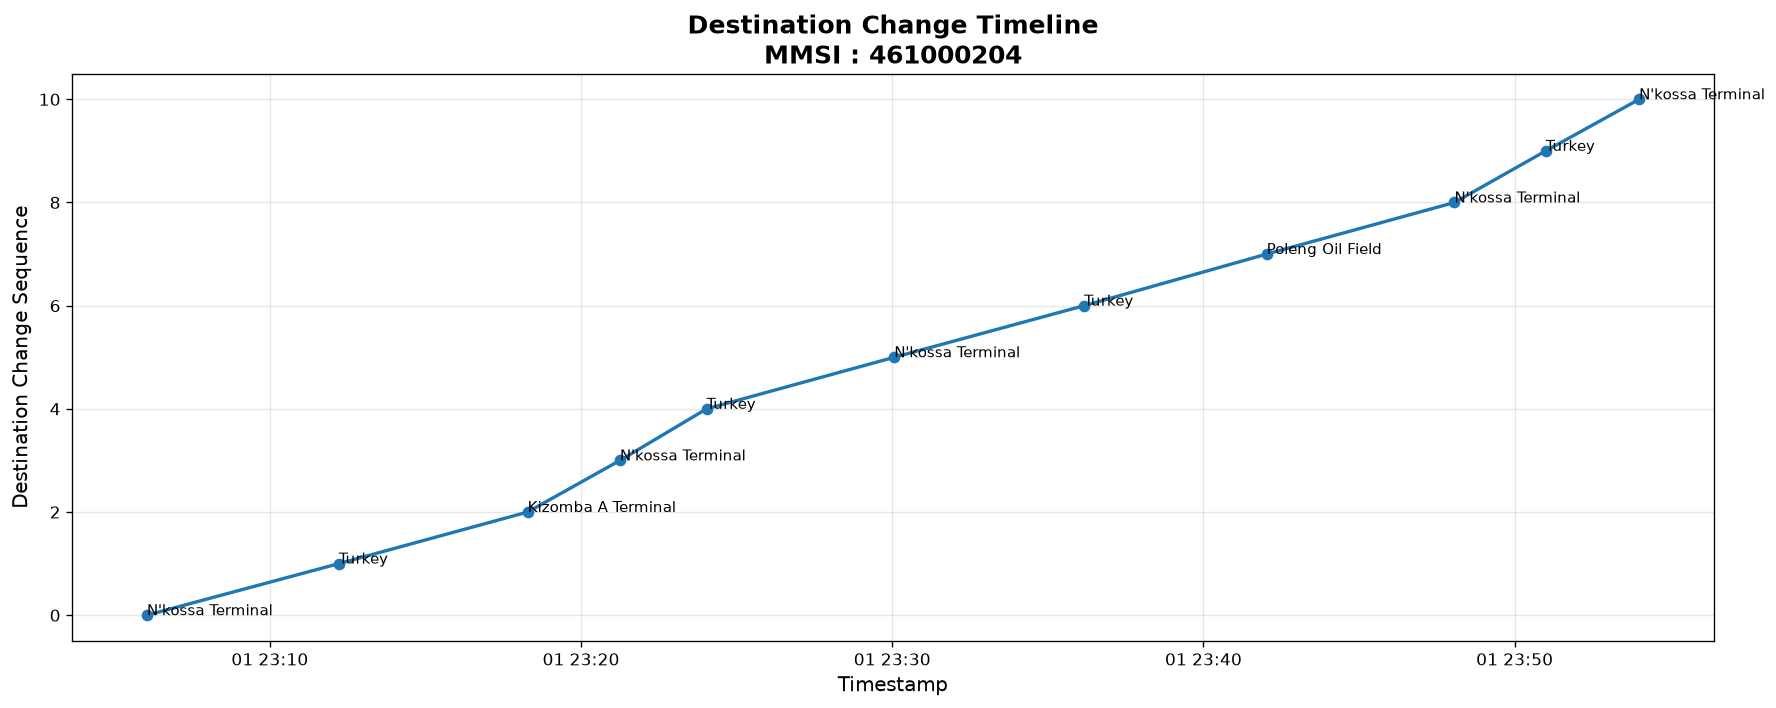

In [84]:
# ==========================================================
# Cell 22 : Destination Change Timeline
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Select Vessel
# ----------------------------------------------------------

selected_mmsi = (
    vessel_summary
    .sort_values(
        "destination_change_count",
        ascending=False
    )
    .iloc[0]["mmsi"]
)

timeline = (
    destination_change_events[
        destination_change_events["mmsi"] == selected_mmsi
    ]
    .sort_values("current_timestamp")
)

plt.figure(figsize=(15,6))

plt.plot(
    timeline["current_timestamp"],
    range(len(timeline)),
    marker="o",
    linewidth=2
)

# Destination labels

for i, row in enumerate(timeline.itertuples()):

    plt.text(
        row.current_timestamp,
        i,
        row.current_destination,
        fontsize=9,
        ha="left"
    )

plt.title(
    f"Destination Change Timeline\nMMSI : {selected_mmsi}",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Timestamp")

plt.ylabel("Destination Change Sequence")

plt.grid(True)

plt.tight_layout()

plt.show()

In [85]:
# ==========================================================
# Cell 23 : Recent Destination Changes
# ==========================================================

recent_changes = (

    destination_change_events

    .sort_values(
        "current_timestamp",
        ascending=False
    )

)

print("="*120)

print("MOST RECENT DESTINATION CHANGES")

print("="*120)

display(

    recent_changes[
        [
            "mmsi",
            "previous_destination",
            "current_destination",
            "previous_timestamp",
            "current_timestamp",
            "time_gap_hours"
        ]
    ].head(20)

)

MOST RECENT DESTINATION CHANGES


,mmsi,previous_destination,current_destination,previous_timestamp,current_timestamp,time_gap_hours
378667,466250000,General Santos,Corpach,2026-06-01 23:53:19+00:00,2026-06-01 23:59:59+00:00,0.111111
265966,413268980,China,Wenzhou,2026-06-01 23:53:01+00:00,2026-06-01 23:59:59+00:00,0.116111
82083,305027400,Blaine,Oman,2026-06-01 23:56:37+00:00,2026-06-01 23:59:50+00:00,0.053611
432819,525006047,Tg. Sorong,Tuban,2026-06-01 23:56:50+00:00,2026-06-01 23:59:49+00:00,0.049722
235206,405000246,India,Bangladesh,2026-06-01 23:55:42+00:00,2026-06-01 23:59:47+00:00,0.068056
357800,422336699,Japan,Huangpu,2026-06-01 23:54:33+00:00,2026-06-01 23:59:45+00:00,0.086667
608037,563097100,Peru,Port Wing,2026-06-01 23:56:38+00:00,2026-06-01 23:59:38+00:00,0.050000
34345,232064745,Al Jubayl,Ju Aymah Oil Terminal,2026-06-01 23:54:34+00:00,2026-06-01 23:59:36+00:00,0.083889
572652,538012480,Iran,Malaysia,2026-06-01 23:53:20+00:00,2026-06-01 23:59:31+00:00,0.103056
117928,352001481,North Ain Sukhna Port,Port Socony,2026-06-01 23:56:55+00:00,2026-06-01 23:59:25+00:00,0.041667


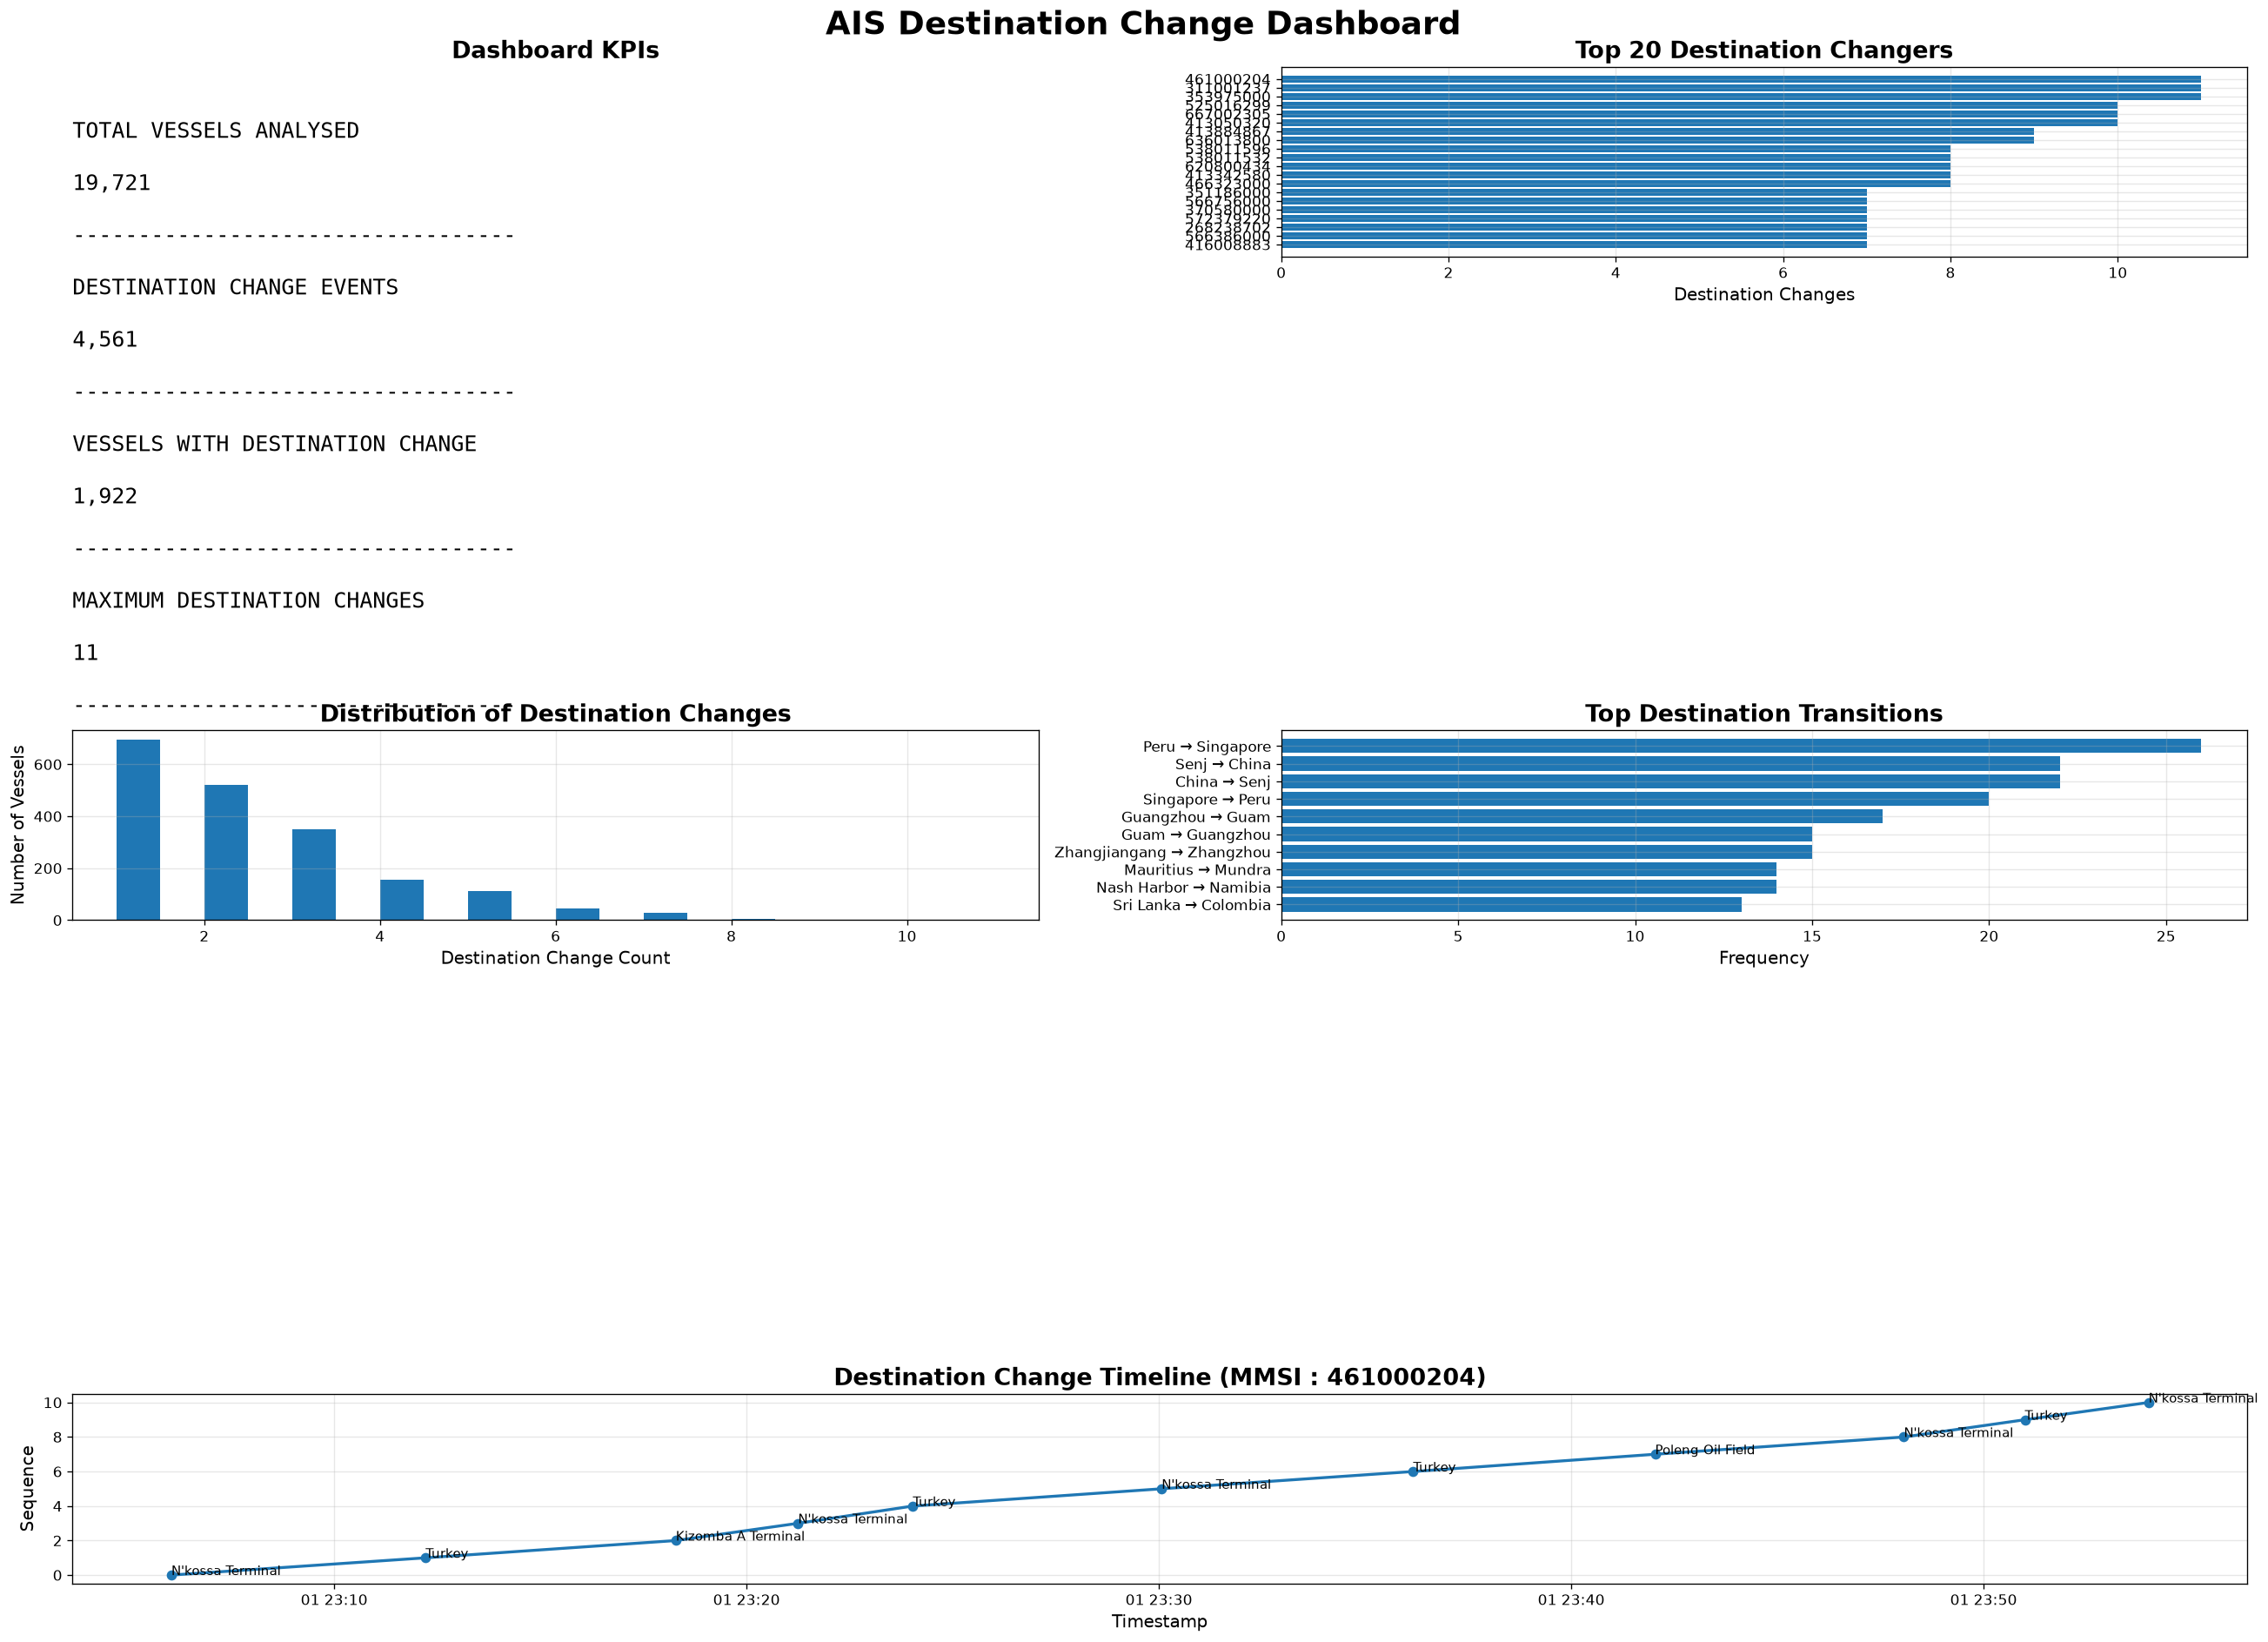

In [86]:
# ==========================================================
# Cell 24 : Destination Change Dashboard
# ==========================================================

import matplotlib.pyplot as plt

# -----------------------------
# Prepare Data
# -----------------------------

top20 = (
    vessel_summary
    .sort_values(
        "destination_change_count",
        ascending=False
    )
    .head(20)
)

transition_top = (
    destination_transitions
    .sort_values(
        "transition_count",
        ascending=False
    )
    .head(10)
)

transition_top["Transition"] = (
    transition_top["previous_destination"]
    + " → " +
    transition_top["current_destination"]
)

selected_mmsi = top20.iloc[0]["mmsi"]

timeline = (
    destination_change_events[
        destination_change_events["mmsi"] == selected_mmsi
    ]
    .sort_values("current_timestamp")
)

# -----------------------------
# Dashboard Figure
# -----------------------------

fig = plt.figure(figsize=(22,16))

fig.suptitle(
    "AIS Destination Change Dashboard",
    fontsize=22,
    fontweight="bold"
)

# ==========================================================
# KPI PANEL
# ==========================================================

ax1 = plt.subplot2grid((3,2),(0,0))

ax1.axis("off")

kpi_text = f"""

TOTAL VESSELS ANALYSED

{total_vessels:,}

----------------------------------

DESTINATION CHANGE EVENTS

{total_change_events:,}

----------------------------------

VESSELS WITH DESTINATION CHANGE

{vessels_with_changes:,}

----------------------------------

MAXIMUM DESTINATION CHANGES

{max_changes}

----------------------------------

AVERAGE DESTINATION CHANGES

{average_changes:.2f}

"""

ax1.text(
    0,
    1,
    kpi_text,
    fontsize=15,
    va="top",
    family="monospace"
)

ax1.set_title(
    "Dashboard KPIs",
    fontsize=16,
    fontweight="bold"
)

# ==========================================================
# TOP 20 DESTINATION CHANGERS
# ==========================================================

ax2 = plt.subplot2grid((3,2),(0,1))

ax2.barh(
    top20["mmsi"].astype(str),
    top20["destination_change_count"]
)

ax2.invert_yaxis()

ax2.set_title(
    "Top 20 Destination Changers",
    fontsize=16,
    fontweight="bold"
)

ax2.set_xlabel("Destination Changes")

# ==========================================================
# DISTRIBUTION
# ==========================================================

ax3 = plt.subplot2grid((3,2),(1,0))

ax3.hist(
    vessel_summary["destination_change_count"],
    bins=20
)

ax3.set_title(
    "Distribution of Destination Changes",
    fontsize=16,
    fontweight="bold"
)

ax3.set_xlabel("Destination Change Count")

ax3.set_ylabel("Number of Vessels")

# ==========================================================
# TOP TRANSITIONS
# ==========================================================

ax4 = plt.subplot2grid((3,2),(1,1))

ax4.barh(
    transition_top["Transition"],
    transition_top["transition_count"]
)

ax4.invert_yaxis()

ax4.set_title(
    "Top Destination Transitions",
    fontsize=16,
    fontweight="bold"
)

ax4.set_xlabel("Frequency")

# ==========================================================
# TIMELINE
# ==========================================================

ax5 = plt.subplot2grid((3,2),(2,0),colspan=2)

ax5.plot(
    timeline["current_timestamp"],
    range(len(timeline)),
    marker="o",
    linewidth=2
)

for i,row in enumerate(timeline.itertuples()):

    ax5.text(
        row.current_timestamp,
        i,
        row.current_destination,
        fontsize=9
    )

ax5.set_title(
    f"Destination Change Timeline (MMSI : {selected_mmsi})",
    fontsize=16,
    fontweight="bold"
)

ax5.set_xlabel("Timestamp")

ax5.set_ylabel("Sequence")

plt.tight_layout()

plt.show()

In [87]:
# ==========================================================
# Dataset Time Range
# ==========================================================

# Ensure timestamp column is datetime
destination_df["timestamp_updated"] = pd.to_datetime(
    destination_df["timestamp_updated"],
    errors="coerce"
)

# Get start and end timestamps
start_time = destination_df["timestamp_updated"].min()
end_time = destination_df["timestamp_updated"].max()

# Calculate total duration
duration = end_time - start_time

print("=" * 70)
print("DATASET TIME RANGE")
print("=" * 70)

print(f"Start Date & Time : {start_time}")
print(f"End Date & Time   : {end_time}")
print(f"Total Time Span   : {duration}")

print("=" * 70)

DATASET TIME RANGE
Start Date & Time : 2026-06-01 23:00:00+00:00
End Date & Time   : 2026-06-01 23:59:59+00:00
Total Time Span   : 0 days 00:59:59


In [88]:
# ==========================================================
# Dataset Time Range (Detailed)
# ==========================================================

start_time = destination_df["timestamp_updated"].min()
end_time = destination_df["timestamp_updated"].max()

duration = end_time - start_time

days = duration.days
hours = duration.seconds // 3600
minutes = (duration.seconds % 3600) // 60

print("=" * 70)
print("AIS DATASET COVERAGE")
print("=" * 70)

print(f"Dataset Start : {start_time}")
print(f"Dataset End   : {end_time}")
print(f"Coverage      : {days} Days, {hours} Hours, {minutes} Minutes")

print("=" * 70)

AIS DATASET COVERAGE
Dataset Start : 2026-06-01 23:00:00+00:00
Dataset End   : 2026-06-01 23:59:59+00:00
Coverage      : 0 Days, 0 Hours, 59 Minutes


In [89]:
#Which vessels follow similar destination sequences?
#Which vessels change destinations at similar rates?
#Which vessels repeatedly switch between the same ports?
#Which vessels exhibit coordinated or highly similar operational behaviour?

In [90]:
# ==========================================================
# Cell 26 : Create Destination Sequence per Vessel
# ==========================================================

print("=" * 70)
print("CREATING DESTINATION SEQUENCES")
print("=" * 70)

# Ensure records are in chronological order
destination_df = destination_df.sort_values(
    ["mmsi", "timestamp_updated"]
)

# Function to remove consecutive duplicate destinations
def compress_sequence(destinations):
    sequence = []
    previous = None

    for destination in destinations:
        if destination != previous:
            sequence.append(destination)
            previous = destination

    return sequence

# Create one sequence per vessel
destination_sequences = (
    destination_df
    .groupby("mmsi")["destination"]
    .apply(compress_sequence)
    .reset_index(name="destination_sequence")
)

# Number of unique destinations visited in the sequence
destination_sequences["unique_destinations"] = (
    destination_sequences["destination_sequence"]
    .apply(len)
)

print(f"Total Vessels : {len(destination_sequences):,}")

display(destination_sequences.head())

CREATING DESTINATION SEQUENCES
Total Vessels : 19,721


,mmsi,destination_sequence,unique_destinations
0,999,[FOR ORDERS],1
1,1111,[Trapani],1
2,171069,[Marin],1
3,420393,"[Saint Helena, Ascension, and Tristan da Cunha]",1
4,998279,[Kin Wan],1


In [91]:
# ==========================================================
# Cell 27 : Destination Change Rate Analysis
# ==========================================================

print("="*70)
print("CALCULATING DESTINATION CHANGE RATE")
print("="*70)

# Observation period for each vessel
observation_period = (

    destination_df

    .groupby("mmsi")

    .agg(
        first_report=("timestamp_updated","min"),
        last_report=("timestamp_updated","max")
    )

    .reset_index()

)

observation_period["observation_days"] = (

    observation_period["last_report"]

    -

    observation_period["first_report"]

).dt.total_seconds()/86400

# Prevent divide-by-zero
observation_period["observation_days"] = observation_period[
    "observation_days"
].replace(0,1)

# Merge with vessel summary
behaviour_profile = vessel_summary.merge(

    observation_period[
        [
            "mmsi",
            "observation_days"
        ]
    ],

    on="mmsi",

    how="left"

)

behaviour_profile["changes_per_day"] = (

    behaviour_profile["destination_change_count"]

    /

    behaviour_profile["observation_days"]

).round(2)

display(behaviour_profile.head())

CALCULATING DESTINATION CHANGE RATE


,mmsi,destination_change_count,avg_time_gap_hours,min_time_gap_hours,max_time_gap_hours,first_change,latest_change,total_reports,observation_days,changes_per_day
0,20127875,5,0.07,0.05,0.10,2026-06-01 23:11:14+00:00,2026-06-01 23:50:10+00:00,16,0.039606,126.24
1,111000000,1,0.01,0.01,0.01,2026-06-01 23:26:54+00:00,2026-06-01 23:27:13+00:00,246,0.041551,24.07
2,205268000,2,0.08,0.05,0.10,2026-06-01 23:38:02+00:00,2026-06-01 23:50:05+00:00,22,0.038044,52.57
3,205664000,2,0.06,0.05,0.07,2026-06-01 23:21:55+00:00,2026-06-01 23:31:01+00:00,28,0.040845,48.97
4,205744000,3,0.08,0.05,0.10,2026-06-01 23:28:48+00:00,2026-06-01 23:49:49+00:00,21,0.035498,84.51


In [92]:
# ==========================================================
# Cell 28 : Destination Stability Index
# Self-contained version
# ==========================================================

print("=" * 70)
print("CALCULATING DESTINATION STABILITY")
print("=" * 70)

# ----------------------------------------------------------
# Create total reports per vessel from the original dataset
# ----------------------------------------------------------

total_reports_df = (
    destination_df
    .groupby("mmsi")
    .size()
    .reset_index(name="total_reports")
)

# ----------------------------------------------------------
# Remove any existing total_reports columns to avoid conflicts
# ----------------------------------------------------------

cols_to_drop = [
    col for col in behaviour_profile.columns
    if col.startswith("total_reports")
]

if cols_to_drop:
    behaviour_profile = behaviour_profile.drop(columns=cols_to_drop)

# ----------------------------------------------------------
# Merge fresh total_reports
# ----------------------------------------------------------

behaviour_profile = behaviour_profile.merge(
    total_reports_df,
    on="mmsi",
    how="left"
)

# ----------------------------------------------------------
# Calculate Stability Index
# ----------------------------------------------------------

behaviour_profile["stability_index"] = (
    behaviour_profile["destination_change_count"] /
    behaviour_profile["total_reports"]
).round(4)

# ----------------------------------------------------------
# Display Result
# ----------------------------------------------------------

display(
    behaviour_profile[
        [
            "mmsi",
            "destination_change_count",
            "total_reports",
            "stability_index"
        ]
    ].head()
)

print("\n✅ Destination Stability Index calculated successfully.")

CALCULATING DESTINATION STABILITY


,mmsi,destination_change_count,total_reports,stability_index
0,20127875,5,16,0.3125
1,111000000,1,246,0.0041
2,205268000,2,22,0.0909
3,205664000,2,28,0.0714
4,205744000,3,21,0.1429



✅ Destination Stability Index calculated successfully.


In [93]:
# ==========================================================
# Cell 29 : Detect Repeated Port Switching
# ==========================================================

print("="*70)
print("DETECTING REPETITIVE PORT SWITCHING")
print("="*70)

switch_records = []

for vessel, group in destination_change_events.groupby("mmsi"):

    group = group.sort_values("current_timestamp")

    destinations = group["current_destination"].tolist()

    count = 0

    for i in range(len(destinations)-3):

        if (

            destinations[i] == destinations[i+2]

            and

            destinations[i+1] == destinations[i+3]

        ):

            count += 1

    switch_records.append(

        {

            "mmsi":vessel,

            "repeated_switch_count":count

        }

    )

repeated_switch_df = pd.DataFrame(switch_records)

display(

    repeated_switch_df.sort_values(

        "repeated_switch_count",

        ascending=False

    ).head(20)

)

DETECTING REPETITIVE PORT SWITCHING


,mmsi,repeated_switch_count
1898,667002305,7
260,353975000,5
1428,538011596,5
754,413856723,4
1624,566756000,4
1766,636013800,4
1196,525016299,4
1882,636093368,4
1407,538009446,4
196,352003482,4


In [94]:
# ==========================================================
# Cell 30 : Master Behaviour Profile
# ==========================================================

behaviour_profile = behaviour_profile.merge(

    destination_sequences,

    on="mmsi",

    how="left"

)

behaviour_profile = behaviour_profile.merge(

    repeated_switch_df,

    on="mmsi",

    how="left"

)

behaviour_profile["repeated_switch_count"] = (

    behaviour_profile["repeated_switch_count"]

    .fillna(0)

    .astype(int)

)

display(behaviour_profile.head())

,mmsi,destination_change_count,avg_time_gap_hours,min_time_gap_hours,max_time_gap_hours,first_change,latest_change,observation_days,changes_per_day,total_reports,stability_index,destination_sequence,unique_destinations,repeated_switch_count
0,20127875,5,0.07,0.05,0.10,2026-06-01 23:11:14+00:00,2026-06-01 23:50:10+00:00,0.039606,126.24,16,0.3125,"[Al Khair Oil Terminal, Angola, Al Khair Oil T...",6,0
1,111000000,1,0.01,0.01,0.01,2026-06-01 23:26:54+00:00,2026-06-01 23:27:13+00:00,0.041551,24.07,246,0.0041,"[Turkey, Phsar Ream]",2,0
2,205268000,2,0.08,0.05,0.10,2026-06-01 23:38:02+00:00,2026-06-01 23:50:05+00:00,0.038044,52.57,22,0.0909,"[Peru, Singapore, Peru]",3,0
3,205664000,2,0.06,0.05,0.07,2026-06-01 23:21:55+00:00,2026-06-01 23:31:01+00:00,0.040845,48.97,28,0.0714,"[Philippines, China, Philippines]",3,0
4,205744000,3,0.08,0.05,0.10,2026-06-01 23:28:48+00:00,2026-06-01 23:49:49+00:00,0.035498,84.51,21,0.1429,"[Sea Eagle Terminal, Singapore, Sea Eagle Term...",4,0


In [95]:
# # ==========================================================
# # Cell 31 : Export Behaviour Profile
# # ==========================================================

# behaviour_profile.to_csv(

#     "Behaviour_Profile.csv",

#     index=False

# )

# print("="*60)

# print("Behaviour Profile Exported Successfully")

# print("="*60)

# print("Saved As : Behaviour_Profile.csv")

In [96]:
# So far, we've created the data needed to answer the questions. Think of it as preparing the features.

#Which vessels follow similar destination sequences?
#Which vessels change destinations at similar rates?
#Which vessels repeatedly switch between the same ports?
#Which vessels exhibit coordinated or highly similar operational behaviour?

In [97]:
pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag

In [98]:
# ==========================================================
# Check Total Unique Vessels
# ==========================================================

total_vessels = destination_df["mmsi"].nunique()

print("=" * 60)
print("TOTAL UNIQUE VESSELS")
print("=" * 60)
print(f"Unique MMSI Count : {total_vessels:,}")

TOTAL UNIQUE VESSELS
Unique MMSI Count : 19,721


In [99]:
# ==========================================================
# Cell 32 : Prepare Behaviour Features
# ==========================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("CELL 32 : PREPARING VESSEL BEHAVIOUR FEATURES")
print("=" * 80)

# ----------------------------------------------------------
# Calculate observation period
# ----------------------------------------------------------

observation = (
    destination_df
    .groupby("mmsi")
    .agg(
        first_report=("timestamp_updated", "min"),
        last_report=("timestamp_updated", "max")
    )
    .reset_index()
)

observation["observation_days"] = (
    (
        observation["last_report"] -
        observation["first_report"]
    ).dt.total_seconds() / 86400
)

# Prevent divide-by-zero
observation["observation_days"] = (
    observation["observation_days"]
    .clip(lower=1)
)

# ----------------------------------------------------------
# Total AIS reports
# ----------------------------------------------------------

total_reports = (
    destination_df
    .groupby("mmsi")
    .size()
    .reset_index(name="total_reports")
)

# ----------------------------------------------------------
# Unique destinations
# ----------------------------------------------------------

unique_destinations = (
    destination_df
    .groupby("mmsi")["destination"]
    .nunique()
    .reset_index(name="unique_destinations")
)

# ----------------------------------------------------------
# Destination changes
# ----------------------------------------------------------

destination_changes = (
    destination_change_events
    .groupby("mmsi")
    .size()
    .reset_index(name="destination_change_count")
)

# ----------------------------------------------------------
# Merge all metrics
# ----------------------------------------------------------

behaviour_features = (
    observation
    .merge(total_reports, on="mmsi", how="left")
    .merge(unique_destinations, on="mmsi", how="left")
    .merge(destination_changes, on="mmsi", how="left")
)

behaviour_features["destination_change_count"] = (
    behaviour_features["destination_change_count"]
    .fillna(0)
)

# ----------------------------------------------------------
# Destination change rate
# ----------------------------------------------------------

behaviour_features["changes_per_day"] = (
    behaviour_features["destination_change_count"] /
    behaviour_features["observation_days"]
)

# ----------------------------------------------------------
# Stability Index
# Higher value = More stable
# ----------------------------------------------------------

behaviour_features["stability_index"] = (
    1 -
    (
        behaviour_features["destination_change_count"] /
        behaviour_features["total_reports"]
    )
)

behaviour_features["stability_index"] = (
    behaviour_features["stability_index"]
    .clip(lower=0)
)

print("\nBehaviour Feature Table Created Successfully\n")

print(f"Total Vessels : {len(behaviour_features):,}")

display(behaviour_features.head())

print("\nColumns Available:\n")

print(behaviour_features.columns.tolist())

CELL 32 : PREPARING VESSEL BEHAVIOUR FEATURES

Behaviour Feature Table Created Successfully

Total Vessels : 19,721


,mmsi,first_report,last_report,observation_days,total_reports,unique_destinations,destination_change_count,changes_per_day,stability_index
0,999,2026-06-01 23:00:03+00:00,2026-06-01 23:45:22+00:00,1.0,3,1,0.0,0.0,1.0
1,1111,2026-06-01 23:00:54+00:00,2026-06-01 23:26:05+00:00,1.0,5,1,0.0,0.0,1.0
2,171069,2026-06-01 23:03:46+00:00,2026-06-01 23:03:46+00:00,1.0,1,1,0.0,0.0,1.0
3,420393,2026-06-01 23:16:49+00:00,2026-06-01 23:49:49+00:00,1.0,4,1,0.0,0.0,1.0
4,998279,2026-06-01 23:57:46+00:00,2026-06-01 23:57:46+00:00,1.0,1,1,0.0,0.0,1.0



Columns Available:

['mmsi', 'first_report', 'last_report', 'observation_days', 'total_reports', 'unique_destinations', 'destination_change_count', 'changes_per_day', 'stability_index']


In [100]:
# ==========================================================
# Cell 33 : Create Ordered Destination Sequences
# ==========================================================

print("=" * 80)
print("CELL 33 : CREATING ORDERED DESTINATION SEQUENCES")
print("=" * 80)

# ----------------------------------------------------------
# Required Columns
# ----------------------------------------------------------

sequence_df = destination_df[
    [
        "mmsi",
        "timestamp_updated",
        "destination"
    ]
].copy()

# ----------------------------------------------------------
# Remove Missing Destinations
# ----------------------------------------------------------

sequence_df["destination"] = (
    sequence_df["destination"]
    .fillna("")
    .astype(str)
    .str.strip()
)

sequence_df = sequence_df[
    sequence_df["destination"] != ""
].copy()

# ----------------------------------------------------------
# Sort Chronologically
# ----------------------------------------------------------

sequence_df = sequence_df.sort_values(
    by=[
        "mmsi",
        "timestamp_updated"
    ]
)

# ----------------------------------------------------------
# Function to Remove Consecutive Duplicate Destinations
# Example:
#
# Singapore
# Singapore
# Singapore
# China
# China
# Japan
#
# becomes
#
# Singapore
# China
# Japan
# ----------------------------------------------------------

def remove_consecutive_duplicates(destination_list):

    cleaned = []

    previous = None

    for dest in destination_list:

        if dest != previous:

            cleaned.append(dest)

            previous = dest

    return cleaned

# ----------------------------------------------------------
# Create Ordered Destination Sequence
# ----------------------------------------------------------

destination_sequences = (

    sequence_df

    .groupby("mmsi")["destination"]

    .apply(list)

    .apply(remove_consecutive_duplicates)

    .reset_index(name="destination_sequence")

)

# ----------------------------------------------------------
# Sequence Length
# ----------------------------------------------------------

destination_sequences["sequence_length"] = (

    destination_sequences["destination_sequence"]

    .apply(len)

)

# ----------------------------------------------------------
# Journey String (Useful for Dashboard)
# ----------------------------------------------------------

destination_sequences["journey"] = (

    destination_sequences["destination_sequence"]

    .apply(

        lambda x: " → ".join(x)

    )

)

# ----------------------------------------------------------
# Display Results
# ----------------------------------------------------------

print("\nOrdered Destination Sequences Created Successfully\n")

print(f"Total Vessels : {len(destination_sequences):,}")

print(f"Average Journey Length : {destination_sequences['sequence_length'].mean():.2f}")

print(f"Maximum Journey Length : {destination_sequences['sequence_length'].max()}")

display(destination_sequences.head())

# ----------------------------------------------------------
# Sequence Length Distribution
# ----------------------------------------------------------

print("\nSequence Length Statistics\n")

display(

    destination_sequences["sequence_length"]

    .describe()

)

# ----------------------------------------------------------
# Example Journey
# ----------------------------------------------------------

print("\nExample Vessel Journey\n")

example = destination_sequences.iloc[0]

print("MMSI :", example["mmsi"])

print("\nJourney\n")

print(example["journey"])

CELL 33 : CREATING ORDERED DESTINATION SEQUENCES

Ordered Destination Sequences Created Successfully

Total Vessels : 19,721
Average Journey Length : 1.23
Maximum Journey Length : 12


,mmsi,destination_sequence,sequence_length,journey
0,999,[FOR ORDERS],1,FOR ORDERS
1,1111,[Trapani],1,Trapani
2,171069,[Marin],1,Marin
3,420393,"[Saint Helena, Ascension, and Tristan da Cunha]",1,"Saint Helena, Ascension, and Tristan da Cunha"
4,998279,[Kin Wan],1,Kin Wan



Sequence Length Statistics



count    19721.000000
mean         1.231276
std          0.851563
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         12.000000
Name: sequence_length, dtype: float64


Example Vessel Journey

MMSI : 999

Journey

FOR ORDERS


In [101]:
# ==========================================================
# Cell 34 : Create Ordered Transition Sequences
# ==========================================================

print("=" * 80)
print("CELL 34 : CREATING ORDERED TRANSITION SEQUENCES")
print("=" * 80)

# ----------------------------------------------------------
# Required Columns
# ----------------------------------------------------------

transition_df = destination_df[
    [
        "mmsi",
        "timestamp_updated",
        "destination"
    ]
].copy()

# ----------------------------------------------------------
# Basic Cleaning
# ----------------------------------------------------------

transition_df["destination"] = (
    transition_df["destination"]
    .fillna("")
    .astype(str)
    .str.strip()
)

transition_df = transition_df[
    transition_df["destination"] != ""
].copy()

# ----------------------------------------------------------
# Sort Chronologically
# ----------------------------------------------------------

transition_df = transition_df.sort_values(
    ["mmsi", "timestamp_updated"]
)

# ----------------------------------------------------------
# Remove Consecutive Duplicate Destinations
# ----------------------------------------------------------

def remove_consecutive_duplicates(destinations):

    cleaned = []
    previous = None

    for dest in destinations:

        if dest != previous:
            cleaned.append(dest)
            previous = dest

    return cleaned

# ----------------------------------------------------------
# Ordered Destination List
# ----------------------------------------------------------

ordered_destinations = (

    transition_df

    .groupby("mmsi")["destination"]

    .apply(list)

    .apply(remove_consecutive_duplicates)

)

# ----------------------------------------------------------
# Convert Destination List
# into Ordered Transition List
#
# Example
#
# Singapore
# China
# Japan
#
# becomes
#
# Singapore → China
# China → Japan
# ----------------------------------------------------------

def create_transition_list(destination_list):

    transitions = []

    if len(destination_list) < 2:
        return transitions

    for i in range(len(destination_list)-1):

        transitions.append(

            destination_list[i]

            + " → "

            + destination_list[i+1]

        )

    return transitions

# ----------------------------------------------------------
# Create Transition DataFrame
# ----------------------------------------------------------

transition_sequences = (

    ordered_destinations

    .apply(create_transition_list)

    .reset_index(name="transition_sequence")

)

# ----------------------------------------------------------
# Transition Count
# ----------------------------------------------------------

transition_sequences["transition_count"] = (

    transition_sequences["transition_sequence"]

    .apply(len)

)

# ----------------------------------------------------------
# Transition String
# Useful for Dashboard
# ----------------------------------------------------------

transition_sequences["transition_path"] = (

    transition_sequences["transition_sequence"]

    .apply(

        lambda x:

        " | ".join(x)

    )

)

# ----------------------------------------------------------
# Merge Journey Length
# ----------------------------------------------------------

transition_sequences = transition_sequences.merge(

    destination_sequences[

        [

            "mmsi",

            "sequence_length"

        ]

    ],

    on="mmsi",

    how="left"

)

# ----------------------------------------------------------
# Statistics
# ----------------------------------------------------------

print("\nTransition Sequences Created Successfully\n")

print(f"Total Vessels : {len(transition_sequences):,}")

print(
    f"Average Transition Count : "
    f"{transition_sequences['transition_count'].mean():.2f}"
)

print(
    f"Maximum Transition Count : "
    f"{transition_sequences['transition_count'].max()}"
)

# ----------------------------------------------------------
# Display Sample
# ----------------------------------------------------------

display(transition_sequences.head())

# ----------------------------------------------------------
# Transition Statistics
# ----------------------------------------------------------

print("\nTransition Count Statistics\n")

display(

    transition_sequences["transition_count"]

    .describe()

)

# ----------------------------------------------------------
# Example Vessel
# ----------------------------------------------------------

example = transition_sequences.iloc[0]

print("\nExample MMSI")

print(example["mmsi"])

print("\nOrdered Transition Path\n")

print(example["transition_path"])

CELL 34 : CREATING ORDERED TRANSITION SEQUENCES

Transition Sequences Created Successfully

Total Vessels : 19,721
Average Transition Count : 0.23
Maximum Transition Count : 11


,mmsi,transition_sequence,transition_count,transition_path,sequence_length
0,999,[],0,,1
1,1111,[],0,,1
2,171069,[],0,,1
3,420393,[],0,,1
4,998279,[],0,,1



Transition Count Statistics



count    19721.000000
mean         0.231276
std          0.851563
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         11.000000
Name: transition_count, dtype: float64


Example MMSI
999

Ordered Transition Path




In [102]:
# ==========================================================
# Cell 35 : Calculate Improved Destination Change Rate
# ==========================================================

print("=" * 80)
print("CELL 35 : CALCULATING DESTINATION CHANGE RATE")
print("=" * 80)

# ----------------------------------------------------------
# Calculate Observation Duration
# ----------------------------------------------------------

observation_time = (

    destination_df

    .groupby("mmsi")

    .agg(

        first_report=("timestamp_updated", "min"),

        last_report=("timestamp_updated", "max")

    )

    .reset_index()

)

# ----------------------------------------------------------
# Observation Hours
# ----------------------------------------------------------

observation_time["observation_hours"] = (

    (

        observation_time["last_report"]

        -

        observation_time["first_report"]

    ).dt.total_seconds()

    / 3600

)

# Avoid divide by zero

observation_time["observation_hours"] = (

    observation_time["observation_hours"]

    .clip(lower=1)

)

# ----------------------------------------------------------
# Merge into Behaviour Features
# ----------------------------------------------------------

behaviour_features = behaviour_features.merge(

    observation_time[

        [

            "mmsi",

            "observation_hours"

        ]

    ],

    on="mmsi",

    how="left"

)

# ----------------------------------------------------------
# Destination Change Rate
# ----------------------------------------------------------

behaviour_features["changes_per_hour"] = (

    behaviour_features["destination_change_count"]

    /

    behaviour_features["observation_hours"]

)

behaviour_features["changes_per_day"] = (

    behaviour_features["changes_per_hour"]

    * 24

)

# ----------------------------------------------------------
# Destination Change Category
# ----------------------------------------------------------

conditions = [

    behaviour_features["changes_per_day"] == 0,

    behaviour_features["changes_per_day"] < 1,

    behaviour_features["changes_per_day"] < 5,

    behaviour_features["changes_per_day"] < 10

]

choices = [

    "No Changes",

    "Low",

    "Medium",

    "High"

]

behaviour_features["change_frequency"] = np.select(

    conditions,

    choices,

    default="Very High"

)

# ----------------------------------------------------------
# Statistics
# ----------------------------------------------------------

print("\nDestination Change Rate Calculated Successfully\n")

print(

    behaviour_features[

        [

            "changes_per_hour",

            "changes_per_day"

        ]

    ].describe()

)

print("\nFrequency Distribution\n")

display(

    behaviour_features["change_frequency"]

    .value_counts()

)

print("\nSample\n")

display(

    behaviour_features[

        [

            "mmsi",

            "destination_change_count",

            "observation_hours",

            "changes_per_day",

            "change_frequency"

        ]

    ].head()

)

CELL 35 : CALCULATING DESTINATION CHANGE RATE

Destination Change Rate Calculated Successfully

       changes_per_hour  changes_per_day
count      19721.000000     19721.000000
mean           0.231276         5.550631
std            0.851563        20.437514
min            0.000000         0.000000
25%            0.000000         0.000000
50%            0.000000         0.000000
75%            0.000000         0.000000
max           11.000000       264.000000

Frequency Distribution



change_frequency
No Changes    17799
Very High      1922
Name: count, dtype: int64


Sample



,mmsi,destination_change_count,observation_hours,changes_per_day,change_frequency
0,999,0.0,1.0,0.0,No Changes
1,1111,0.0,1.0,0.0,No Changes
2,171069,0.0,1.0,0.0,No Changes
3,420393,0.0,1.0,0.0,No Changes
4,998279,0.0,1.0,0.0,No Changes


In [103]:
# ==========================================================
# Cell 36 : Calculate Improved Stability Index
# ==========================================================

print("=" * 80)
print("CELL 36 : CALCULATING IMPROVED STABILITY INDEX")
print("=" * 80)

# ----------------------------------------------------------
# Count reports for every Destination of every Vessel
# ----------------------------------------------------------

destination_frequency = (

    destination_df

    .groupby(

        [

            "mmsi",

            "destination"

        ]

    )

    .size()

    .reset_index(name="report_count")

)

# ----------------------------------------------------------
# Total Reports
# ----------------------------------------------------------

total_reports = (

    destination_frequency

    .groupby("mmsi")["report_count"]

    .sum()

    .reset_index(name="total_reports")

)

# ----------------------------------------------------------
# Maximum reports for a single destination
# ----------------------------------------------------------

max_reports = (

    destination_frequency

    .groupby("mmsi")["report_count"]

    .max()

    .reset_index(name="dominant_destination_reports")

)

# ----------------------------------------------------------
# Merge
# ----------------------------------------------------------

stability = (

    total_reports

    .merge(

        max_reports,

        on="mmsi",

        how="left"

    )

)

# ----------------------------------------------------------
# Stability Index
#
# Higher = More Stable
#
# Formula
#
# dominant destination reports
# ----------------------------
# total reports
#
# Example
#
# Singapore 80 reports
# China 15
# Japan 5
#
# Stability = 80 / 100 = 0.80
#
# ----------------------------------------------------------

stability["stability_index"] = (

    stability["dominant_destination_reports"]

    /

    stability["total_reports"]

)

# ----------------------------------------------------------
# Merge into Behaviour Features
# ----------------------------------------------------------

behaviour_features = (

    behaviour_features

    .drop(

        columns=["stability_index"],

        errors="ignore"

    )

    .merge(

        stability[

            [

                "mmsi",

                "stability_index",

                "dominant_destination_reports"

            ]

        ],

        on="mmsi",

        how="left"

    )

)

# ----------------------------------------------------------
# Stability Category
# ----------------------------------------------------------

conditions = [

    behaviour_features["stability_index"] >= 0.90,

    behaviour_features["stability_index"] >= 0.75,

    behaviour_features["stability_index"] >= 0.50,

    behaviour_features["stability_index"] >= 0.25

]

choices = [

    "Very Stable",

    "Stable",

    "Moderate",

    "Unstable"

]

behaviour_features["stability_category"] = np.select(

    conditions,

    choices,

    default="Highly Unstable"

)

# ----------------------------------------------------------
# Statistics
# ----------------------------------------------------------

print("\nStability Index Calculated Successfully\n")

print(

    behaviour_features["stability_index"]

    .describe()

)

print("\nCategory Distribution\n")

display(

    behaviour_features["stability_category"]

    .value_counts()

)

print("\nSample\n")

display(

    behaviour_features[

        [

            "mmsi",

            "total_reports",

            "dominant_destination_reports",

            "stability_index",

            "stability_category"

        ]

    ].head()

)

CELL 36 : CALCULATING IMPROVED STABILITY INDEX



Stability Index Calculated Successfully

count    19721.000000
mean         0.971136
std          0.100559
min          0.203125
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: stability_index, dtype: float64

Category Distribution



stability_category
Very Stable        18116
Moderate            1060
Stable               458
Unstable              86
Highly Unstable        1
Name: count, dtype: int64


Sample



,mmsi,total_reports,dominant_destination_reports,stability_index,stability_category
0,999,3,3,1.0,Very Stable
1,1111,5,5,1.0,Very Stable
2,171069,1,1,1.0,Very Stable
3,420393,4,4,1.0,Very Stable
4,998279,1,1,1.0,Very Stable
